In [1]:
# In[1] — thread caps (fork-safety / reproducibility)
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'

In [2]:
# In[2] — imports, path, reload, confirm the passthrough is in your repo
import sys, os, importlib, warnings, inspect
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [3]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)

FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=True)   # DOY-aware hplc forcing
BASE = {'GGE':0.31,'mP':0.0015,'m_Z':0.10,'KsZ':0.23,'sigma_log':0.20}
MULT = {'m_Z':0.10,'GGE':0.31,'KsZ':0.23,'sigma_log':0.20,'mP':0.0015,'m_Zlin':0.05,
        'k_remin':0.10,'w_sink':5.0,'q10_grow':1.62,'q10_graze':2.48,'mu_scale':1.0,'graze_scale':1.0}
ADD  = {'graze_fD':0.75,'pm_fD':0.9}
FACT = [0.5,0.75,1.25,1.5]; DELT = [-0.30,-0.15,0.15,0.30]
combos=[dict(BASE)]
for p,d in MULT.items():
    for f in FACT: c=dict(BASE); c[p]=round(d*f,6); combos.append(c)
for p,d in ADD.items():
    for a in DELT: c=dict(BASE); c[p]=round(min(1.0,max(0.0,d+a)),4); combos.append(c)
seen=set(); uniq=[]
for c in combos:
    k=tuple(sorted((kk,round(vv,6)) for kk,vv in c.items()))
    if k not in seen: seen.add(k); uniq.append(c)
combos=uniq
print(f"OAT (HPLC-coincident DOY forcing): {len(combos)} sets × 2 eras × 15 r_F = {len(combos)*30} runs")
res = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery','post'],
    fish_rates=list(np.linspace(0.05,0.6,15)), param_combos=combos, years=60, spinup=15,
    n_harmonics=3, forcings=FORC,
    save_path='seasonal_OAT_hplc3h_2026-06-28.pkl', processes=None, maxtasksperchild=1)
print("done:", len(res.records), "records")

OAT (HPLC-coincident DOY forcing): 56 sets × 2 eras × 15 r_F = 1680 runs
[seasonal scan] 1680 runs: ['maranon_ward'] x ['pre+recovery', 'post'] x fish=[np.float64(0.05), np.float64(0.08928571428571427), np.float64(0.12857142857142856), np.float64(0.16785714285714282), np.float64(0.20714285714285713), np.float64(0.24642857142857139), np.float64(0.28571428571428564), np.float64(0.32499999999999996), np.float64(0.3642857142857142), np.float64(0.40357142857142847), np.float64(0.4428571428571428), np.float64(0.48214285714285704), np.float64(0.5214285714285714), np.float64(0.5607142857142856), np.float64(0.6)] x params['GGE', 'KsZ', 'graze_fD', 'graze_scale', 'k_remin', 'mP', 'm_Z', 'm_Zlin', 'mu_scale', 'pm_fD', 'q10_graze', 'q10_grow', 'sigma_log', 'w_sink'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
--- run_parallel_tasks: 1680 tasks, 19 workers (seasonal) ---

baseline construct D: joint=0.254 bloom=M dRF=0.275 Z200_inv=-0.0119 n_clean=2

most bloom-shifting nudges (−d_post_bloom = earlier):
      screw   val  joint  post_bloom   dRF  Z200_inv  n_clean  d_joint  d_post_bloom  d_dRF  d_Zinv
    k_remin 0.150  0.365           2 0.000    -0.052        3    0.110            -1 -0.275  -0.040
   q10_grow 1.215  0.401           2 0.039    -0.039        4    0.147            -1 -0.236  -0.027
  q10_graze 3.100  0.229           2 0.432    -0.004        2   -0.025            -1  0.157   0.008
  q10_graze 3.720  0.250           2 0.511     0.002        2   -0.004            -1  0.236   0.014
    k_remin 0.125  0.296           2 0.275    -0.019        4    0.041            -1  0.000  -0.007
   mu_scale 1.500  0.306           2 0.354    -0.005        0    0.052            -1  0.079   0.007
        GGE 0.232  0.515           2 0.000    -0.029        0    0.260            -1 -0.275  -0.017
     w_sink 3.750  0.304           2 0.314    -0.016        3    0

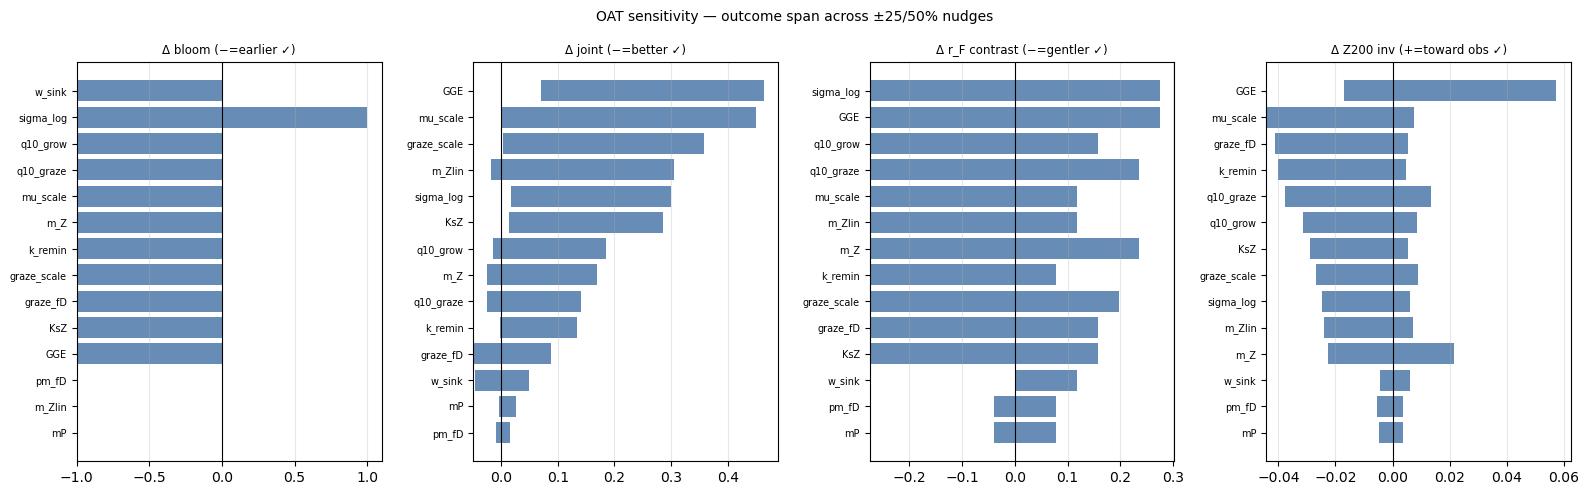

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
import seasonal_scan_harness as ssh

res=ssh.load_results('seasonal_OAT_hplc3h_2026-06-28.pkl'); recs=res.records; OBS=res.obs
obs_m=ssh.build_obs_monthly(['pre+recovery','post'],forcing_complete=True)
MO=['J','F','M','A','M','J','J','A','S','O','N','D']
TGT=['mcs','pico','nano','micro','sumP']; CTOL,NCEIL,FRFLR,SPFLR=0.15,100.,0.02,1e-6
CENTER={'GGE':0.31,'mP':0.0015,'m_Z':0.10,'KsZ':0.23,'sigma_log':0.20,'m_Zlin':0.05,
        'k_remin':0.10,'w_sink':5.0,'q10_grow':1.62,'q10_graze':2.48,'mu_scale':1.0,
        'graze_scale':1.0,'graze_fD':0.75,'pm_fD':0.9}
obb={g:int(np.nanargmax(obs_m[g].dropna(subset=['sumP']).groupby('mo')['sumP'].median().reindex(range(1,13)).values))+1 for g in OBS}
def csc(r):
    g=r['group']
    def rms(get,ov): 
        t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
        return float(np.sqrt(np.mean(t))) if t else np.nan
    return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']),rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
def bmo(r):
    c=np.asarray(r.get('clim_sumP',[np.nan]*12),float); return int(np.nanargmax(c))+1 if np.isfinite(c).any() else np.nan
def flg(r):
    g=r['group']; omn=OBS[g]['mean']; f=''
    if r.get('has_nan') or not(np.isfinite(r.get('sumP',np.nan)) and r['sumP']>SPFLR): f+='X'
    if np.isfinite(r.get('N',np.nan)) and r['N']>NCEIL: f+='N'
    cp=[np.nanmin(np.asarray(r.get('clim_'+k,[np.nan]*12),float)) for k in('pico','nano','micro')]
    if np.isfinite(cp).any() and np.nanmin(cp)<FRFLR: f+='c'
    if omn.get('nano') and np.isfinite(r.get('nano',np.nan)) and r['nano']>omn['nano']*(1+CTOL): f+='n'
    if omn.get('micro') and np.isfinite(r.get('micro',np.nan)) and r['micro']<omn['micro']*(1-CTOL): f+='m'
    bm=bmo(r); ob=obb[g]
    if not(np.isfinite(bm) and np.isfinite(ob) and abs(bm-ob)<=1): f+='b'
    return f
def screw_of(r):
    for k,cv in CENTER.items():
        if abs(float(r.get(k,cv))-cv) > 1e-9*max(1,abs(cv)): return k,float(r.get(k,cv))
    return 'baseline',0.0
for r in recs: r['_sc']=csc(r); r['_fl']=flg(r); r['_bm']=bmo(r); s=screw_of(r); r['_screw'],r['_val']=s
byc=defaultdict(lambda:{'pre+recovery':[],'post':[]})
for r in recs: byc[(r['_screw'],round(r['_val'],6))][r['group']].append(r)
rows=[]
for (screw,val),d in byc.items():
    P=[(max(p['_sc'],q['_sc']),p['fish'],q['fish'],q.get('Z200',np.nan)-p.get('Z200',np.nan),q['_bm'],
        p['_fl']=='' and q['_fl']=='' and np.isfinite(q.get('Z200',np.nan)-p.get('Z200',np.nan)) and (q.get('Z200',0)-p.get('Z200',0))>0)
       for p in d['pre+recovery'] for q in d['post'] if q['fish']<=p['fish']]
    P=[x for x in P if np.isfinite(x[0])]
    if not P: continue
    bj=min(P,key=lambda x:x[0])
    rows.append(dict(screw=screw,val=round(val,4),joint=bj[0],dRF=bj[1]-bj[2],post_bloom=bj[4],
                     Z200_inv=bj[3],n_clean=sum(x[5] for x in P)))
S=pd.DataFrame(rows); b=S[S.screw=='baseline'].iloc[0]
print(f"baseline construct D: joint={b.joint:.3f} bloom={MO[int(b.post_bloom)-1]} dRF={b.dRF:.3f} Z200_inv={b.Z200_inv:+.4f} n_clean={int(b.n_clean)}")
S['d_joint']=S.joint-b.joint; S['d_post_bloom']=S.post_bloom-b.post_bloom
S['d_dRF']=S.dRF-b.dRF; S['d_Zinv']=S.Z200_inv-b.Z200_inv
sc=S[S.screw!='baseline'].copy()
print("\nmost bloom-shifting nudges (−d_post_bloom = earlier):")
print(sc.sort_values('d_post_bloom')[['screw','val','joint','post_bloom','dRF','Z200_inv','n_clean','d_joint','d_post_bloom','d_dRF','d_Zinv']].round(3).head(15).to_string(index=False))
M=[('d_post_bloom','Δ bloom (−=earlier ✓)'),('d_joint','Δ joint (−=better ✓)'),('d_dRF','Δ r_F contrast (−=gentler ✓)'),('d_Zinv','Δ Z200 inv (+=toward obs ✓)')]
fig,axes=plt.subplots(1,4,figsize=(16,5))
for ax,(m,lab) in zip(axes,M):
    g=sc.groupby('screw')[m].agg(['min','max']); g=g.reindex(g.abs().max(axis=1).sort_values().index); y=np.arange(len(g))
    ax.barh(y,g['max']-g['min'],left=g['min'],color='#4C78A8',alpha=0.85); ax.axvline(0,color='k',lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(g.index,fontsize=7); ax.set_title(lab,fontsize=8.5); ax.grid(axis='x',alpha=0.3)
fig.suptitle('OAT sensitivity — outcome span across ±25/50% nudges',fontsize=10); plt.tight_layout(); plt.show()

In [ ]:
# ═══ Fig-4 driver (DISK-CACHED): cycle pickle × ranking, flags filtered ══════
import importlib, pickle, os, numpy as np, pandas as pd, seasonal_scan_harness as ssh

PICKLES = ['seasonal_rF_sweep_hplc3h_2026-06-27.pkl',
           'seasonal_rF_sweep_all3h_2026-06-27.pkl']
PICKLE_IDX   = 0          # ← which file
RANK_IDX     = 0          # ← which pair within the filtered ranking
DROP_FLAGGED = True       # drop pairs with any record flag
REQUIRE_ZDIR = True       # keep only post>pre Z200
PREWARM      = True       # precompute every run in the shortlist now → browsing is instant
PERSIST      = True       # save/restore inspected trajectories to disk (survives kernel restart)
N_HARM       = 3          # MUST match the scan launch
TRAJ_CACHE   = 'traj_cache.pkl'   # NB delete this if you regenerate a scan pickle under the same name

FLAG_KEY = {'X':'collapse / NaN-terminated', 'N':'N runaway (>100)',
            'c':'coexistence loss (a size class ~vanishes)', 'n':'Nano over obs (>+15%)',
            'm':'Micro short of obs (<−15%)', 'b':'ΣP bloom > ±1 month from obs'}

try: _RES_CACHE, _RUN_CACHE                       # persist across re-runs of this cell
except NameError: _RES_CACHE, _RUN_CACHE = {}, {}
if PERSIST and os.path.exists(TRAJ_CACHE) and not _RUN_CACHE:    # restore inspected runs once per kernel
    try:
        with open(TRAJ_CACHE,'rb') as fh: _RUN_CACHE.update(pickle.load(fh))
        print(f"restored {len(_RUN_CACHE)} cached trajectories from {TRAJ_CACHE}")
    except Exception as e:
        print(f"(traj cache load skipped: {e})")
_DIRTY = {'f': False}
def _save_traj_cache():
    if PERSIST and _DIRTY['f']:
        with open(TRAJ_CACHE,'wb') as fh: pickle.dump(_RUN_CACHE, fh)
        _DIRTY['f'] = False

SPEC = ssh.allometry('maranon_ward')

def _rank(path):
    res = ssh.load_results(path); OBS = res.obs; GR = ['pre+recovery', 'post']
    om  = ssh.build_obs_monthly(GR, forcing_complete=True)
    TGT = ['mcs','pico','nano','micro','sumP']; CTOL,NCEIL,FRFLR,SPFLR = 0.15,100.,0.02,1e-6
    obb = {g: (int(np.nanargmax(om[g].dropna(subset=['sumP']).groupby('mo')['sumP']
                    .median().reindex(range(1,13)).values)+1) if om[g]['sumP'].notna().any() else np.nan) for g in GR}
    def csc(r):
        g=r['group']
        def rms(get,ov):
            t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
            return float(np.sqrt(np.mean(t))) if t else np.nan
        return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']), rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
    def bmo(r):
        c=np.asarray(r.get('clim_sumP',[np.nan]*12),float); return int(np.nanargmax(c))+1 if np.isfinite(c).any() else np.nan
    def flg(r):
        g=r['group']; omn=OBS[g]['mean']; f=''
        if r.get('has_nan') or not(np.isfinite(r.get('sumP',np.nan)) and r['sumP']>SPFLR): f+='X'
        if np.isfinite(r.get('N',np.nan)) and r['N']>NCEIL: f+='N'
        cp=[np.nanmin(np.asarray(r.get('clim_'+k,[np.nan]*12),float)) for k in ('pico','nano','micro')]
        if np.isfinite(cp).any() and np.nanmin(cp)<FRFLR: f+='c'
        if omn.get('nano')  and np.isfinite(r.get('nano',  np.nan)) and r['nano'] >omn['nano'] *(1+CTOL): f+='n'
        if omn.get('micro') and np.isfinite(r.get('micro', np.nan)) and r['micro']<omn['micro']*(1-CTOL): f+='m'
        bm=bmo(r); ob=obb[g]
        if not(np.isfinite(bm) and np.isfinite(ob) and abs(bm-ob)<=1): f+='b'
        return f
    A=pd.DataFrame([dict(group=r['group'],fish=r['fish'],score=csc(r),Z200=r.get('Z200',np.nan),
                         flag=flg(r),bloom=bmo(r)) for r in res.records])
    pre,post=A[A.group=='pre+recovery'],A[A.group=='post']; J=[]
    for _,p in pre.iterrows():
        for _,q in post.iterrows():
            if q.fish>p.fish: continue
            J.append(dict(pre_rF=p.fish,post_rF=q.fish,joint=float(np.nanmax([p.score,q.score])),
                          pre_fl=p['flag'] or '·',post_fl=q['flag'] or '·',Zdir=bool(q.Z200-p.Z200>0),Z200_inv=q.Z200-p.Z200))
    return res, A, pd.DataFrame(J)

def _get(path):
    if path not in _RES_CACHE: _RES_CACHE[path]=_rank(path)
    return _RES_CACHE[path]
def _run_cached(path,group,fish):
    key=(path,group,round(float(fish),6),N_HARM)
    if key not in _RUN_CACHE:
        res=_get(path)[0]
        _RUN_CACHE[key]=ssh.run_one(SPEC,res.forcings[group],fish_rate=float(fish),years=60,spinup=15,
                                    mP=0.0015,m_Z=0.10,grazing={'KsZ':0.23,'sigma_log':0.20},
                                    iv_overrides={'GrazingRouter':{'gge':0.31}},n_harmonics=N_HARM,return_traj=True)
        _DIRTY['f']=True
    return _RUN_CACHE[key]

PATH=PICKLES[PICKLE_IDX]; res,A,J=_get(PATH)
sel=J.copy()
if DROP_FLAGGED: sel=sel[(sel.pre_fl=='·')&(sel.post_fl=='·')]
if REQUIRE_ZDIR: sel=sel[sel.Zdir]
sel=sel.sort_values('joint').reset_index(drop=True)
print(f"pickle[{PICKLE_IDX}] {PATH}  | filtered pairs: {len(sel)} (DROP_FLAGGED={DROP_FLAGGED}, REQUIRE_ZDIR={REQUIRE_ZDIR})")
if len(sel)==0:
    print("  !! none survive — falling back to UNFILTERED joint ranking"); sel=J.sort_values('joint').reset_index(drop=True)
print("flag key: " + " | ".join(f"{k}={v}" for k,v in FLAG_KEY.items()))
print(sel.head(10).round(3).to_string())

if PREWARM:
    todo={('pre+recovery',round(float(r.pre_rF),6)) for _,r in sel.iterrows()} | \
         {('post',round(float(r.post_rF),6)) for _,r in sel.iterrows()}
    new=[(g,f) for (g,f) in todo if (PATH,g,f,N_HARM) not in _RUN_CACHE]
    if new:
        print(f"prewarming {len(new)} uncached runs ...",flush=True)
        for g,f in new: _run_cached(PATH,g,f)
        _save_traj_cache()                         # one disk write after the batch

row=sel.iloc[min(RANK_IDX,len(sel)-1)]; PF,QF=float(row.pre_rF),float(row.post_rF)
print(f"\n>>> RANK_IDX={RANK_IDX}:  pre_rF={PF:.3f}  post_rF={QF:.3f}  joint={row.joint:.3f}  "
      f"Z200_inv={row.Z200_inv:+.4f}  flags[{row.pre_fl}/{row.post_fl}]")
ERAS=['pre+recovery','post']; FISH={'pre+recovery':PF,'post':QF}
runs={g:_run_cached(PATH,g,FISH[g])[1] for g in ERAS}
_save_traj_cache()                                 # persist anything new (no-op if all cached)
print(f"cache: {len(_RUN_CACHE)} runs held ({sum(1 for k in _RUN_CACHE if k[0]==PATH)} for this pickle)"
      f"{' | saved to '+TRAJ_CACHE if PERSIST else ''}")

pickle[0] seasonal_rF_sweep_hplc3h_2026-06-27.pkl  | filtered pairs: 7 (DROP_FLAGGED=True, REQUIRE_ZDIR=True)
flag key: X=collapse / NaN-terminated | N=N runaway (>100) | c=coexistence loss (a size class ~vanishes) | n=Nano over obs (>+15%) | m=Micro short of obs (<−15%) | b=ΣP bloom > ±1 month from obs
   pre_rF  post_rF  joint pre_fl post_fl  Zdir  Z200_inv
0   0.562    0.069  0.252      ·       ·  True     0.001
1   0.543    0.069  0.252      ·       ·  True     0.000
2   0.581    0.069  0.252      ·       ·  True     0.001
3   0.562    0.050  0.313      ·       ·  True     0.003
4   0.543    0.050  0.313      ·       ·  True     0.002
5   0.581    0.050  0.313      ·       ·  True     0.002
6   0.600    0.050  0.313      ·       ·  True     0.001
prewarming 6 uncached runs ...


In [ ]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY

SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(doy): return np.interp(np.asarray(doy,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):                                  # obs x at cruise DOY, mo fallback
    d=df.get(col, pd.Series(np.nan,index=df.index)) if hasattr(df,'get') else df[col]
    return np.where(np.isfinite(d), doy_to_mo(d), df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=0.9,hatch=h,edgecolor='k',lw=0.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=0.6,zorder=4)
import pandas as pd
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,0.85,0.85,0.9],hspace=0.5,wspace=0.32)
# Row0 phase (FN–mcs; no time axis → no DOY)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=0.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
# Row1 ΣP seasonal (obs at doy_hplc)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=0.12,lw=0.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=0.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(0.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.nanpercentile(allv,98)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
# Row2 composition seasonal (obs at doy_hplc)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=0.12,lw=0.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=0.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(0.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
# Row3 bars
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-0.5*W,('post','m'):0.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=0.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]} | pre_rF={FISH['pre+recovery']:.3f} post_rF={FISH['post']:.3f}",fontsize=10); plt.tight_layout(); plt.show()

In [ ]:
import seasonal_diagnostics as sd, importlib; importlib.reload(sd)
N_HARM=3; spec=ssh.allometry('maranon_ward'); FORC=res.forcings; OBS_T=res.obs
OBS_M=ssh.build_obs_monthly(['pre+recovery','post'],forcing_complete=True)
def _run(g,fish): return ssh.run_one(spec,FORC[g],fish_rate=float(fish),years=60,spinup=15,mP=0.0015,m_Z=0.10,
    grazing={'KsZ':0.23,'sigma_log':0.20},iv_overrides={'GrazingRouter':{'gge':0.31}},n_harmonics=N_HARM,return_traj=True)
def _fp(df): return (float(df.iloc[0].pre_rF),float(df.iloc[0].post_rF)) if len(df) else (np.nan,np.nan)
Jz=J[J.Z200_inv>0].sort_values('joint'); Jcz=J[(J.pre_fl=='·')&(J.post_fl=='·')&(J.Z200_inv>0)].sort_values('joint')
CANDS=[('TOP joint',*_fp(J.sort_values('joint'))),('TOP Zdir-ok',*_fp(Jz)),('TOP clean & Zdir',*_fp(Jcz)),('committed 0.5/0.1',0.5,0.1)]
for tag,pf,qf in CANDS:
    if not(np.isfinite(pf) and np.isfinite(qf)): print(f"\n### {tag}: n/a"); continue
    print('\n'+'#'*70+f"\n## {tag}: pre_rF={pf:.3f} post_rF={qf:.3f}\n"+'#'*70)
    for g,fish in [('pre+recovery',pf),('post',qf)]:
        clim,r=_run(g,fish); sd.diagnose(clim,r,g,spinup=15,obs_targets=OBS_T,obs_monthly=OBS_M,title=f"\n[{tag} | {g} | r_F={fish:.3f}]")